# V51: Fee Mitigation Strategies (LQ45)

Notebook ini bertujuan untuk **menjinakkan sensitivitas AI** agar tahan terhadap biaya transaksi (Fee 0.25%).
Kita bereksperimen dengan metode moderasi sinyal untuk mengurangi False Alarms yang memicu biaya tinggi.

### Opsi Mitigasi yang Diuji:
1.  **Baseline (V47 Dynamic)**: Sinyal AI murni (Raw Probability). Langsung switch Risk ON/OFF.
2.  **Signal Smoothing (EMA)**: Menggunakan Exponential Moving Average pada probabilitas AI selama **3 hari** dan **5 hari**. Tujuannya menghilangkan 'noise' harian.
3.  **Regime Confirmation**: Menunggu konfirmasi sinyal selama **2 hari** atau **3 hari** berturut-turut sebelum mengubah posisi. Tujuannya menghindari 'whipsaw' (tertipu sinyal palsu sesaat).
4.  **Static Markowitz**: Pembanding (Benchmark) yang selalu invest.

Semua simulasi menggunakan **Fee = 0.25%**.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"Data Loaded: {len(data)} rows")

Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (Standard V47) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: Mitigated Simulation ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_mitigated(test_dates, returns, ai_probs, threshold, 
                             mitigation_type='baseline', # 'baseline', 'smoothing', 'confirmation', 'static'
                             mitigation_param=None, # window size for smoothing, days for confirmation
                             fee=0.0025, 
                             g_lookback=60, 
                             rebal_period=20, 
                             turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False # Default OFF
    
    # State variables for Confirmation Logic
    signal_buffer = []
    
    # Pre-calculate Smoothed Probs for Smoothing Logic
    if mitigation_type == 'smoothing' and mitigation_param:
        # Use EMA for smoothing
        smoothed_probs = ai_probs.ewm(span=mitigation_param, adjust=False).mean()
    else:
        smoothed_probs = ai_probs

    days_since_rebal = 999
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        
        # --- 1. Determine Raw Signal ---
        prob = smoothed_probs.loc[date] # If smoothing, this is already smoothed
        
        # Determine 'Potential' Status based on Threshold with Hysteresis (Buffer)
        # Using basic buffer from V47
        buffer = 0.05
        raw_signal_on = False
        if prob > (threshold + buffer):
            raw_signal_on = True
        elif prob < (threshold - buffer):
            raw_signal_on = False
        else:
            # Start with existing status if in hysteresis zone (neutral zone)
            # But wait, to be strict, let's say > threshold is ON for confirmation logic input
            raw_signal_on = (prob > threshold)

        # --- 2. Apply Mitigation Logic to get Final Risk Status ---
        if mitigation_type == 'static':
            risk_status = True
        elif mitigation_type == 'confirmation':
            # Require N days of consistent signal to switch
            signal_buffer.append(raw_signal_on)
            if len(signal_buffer) > mitigation_param:
                signal_buffer.pop(0)
            
            if len(signal_buffer) == mitigation_param:
                # If all recent signals match, we adopt that state
                if all(signal_buffer): risk_status = True
                elif not any(signal_buffer): risk_status = False
                # Else: Maintain previous risk_status (do nothing)
            else:
                # Not enough data yet, hold previous
                pass
        else: 
            # 'baseline' or 'smoothing' (smoothing handled in prob calculation)
            # Standard Hysteresis Logic
            if not risk_status and prob > (threshold + buffer): risk_status = True
            elif risk_status and prob < (threshold - buffer): risk_status = False
                
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 3. Determine Target Weights ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                # Fee Control
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 4. Execute & Apply Fees ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        cost = 0
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        # --- 5. Return & Drift ---
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    day_ret += w * r
                    new_weights_drifted[asset] = w * (1 + r)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

In [4]:
# --- 4. Run Scenarios ---
test_dates = X_test.index
fee_rate = 0.0025
rebal = 20
buff = 0.05

results = {}

# 1. Static (Benchmark)
print("Running Static...")
res_static = run_simulation_mitigated(test_dates, returns, test_probs, opt_t, 'static', fee=fee_rate)
results['Static Markowitz'] = res_static['Portfolio_Value']

# 2. Baseline AI (Dynamic V47)
print("Running Baseline AI...")
res_base = run_simulation_mitigated(test_dates, returns, test_probs, opt_t, 'baseline', fee=fee_rate)
results['AI Baseline (No Mitigation)'] = res_base['Portfolio_Value']

# 3. Signal Smoothing (EMA 3 & 5 days)
print("Running Smoothing AI(3)...")
res_smooth3 = run_simulation_mitigated(test_dates, returns, test_probs, opt_t, 'smoothing', mitigation_param=3, fee=fee_rate)
results['AI Smoothing (3-Day EMA)'] = res_smooth3['Portfolio_Value']

print("Running Smoothing AI(5)...")
res_smooth5 = run_simulation_mitigated(test_dates, returns, test_probs, opt_t, 'smoothing', mitigation_param=5, fee=fee_rate)
results['AI Smoothing (5-Day EMA)'] = res_smooth5['Portfolio_Value']

# 4. Regime Confirmation (Wait 2 & 3 days)
print("Running Confirmation AI(2)...")
res_conf2 = run_simulation_mitigated(test_dates, returns, test_probs, opt_t, 'confirmation', mitigation_param=2, fee=fee_rate)
results['AI Confirmation (2-Day Wait)'] = res_conf2['Portfolio_Value']

print("Running Confirmation AI(3)...")
res_conf3 = run_simulation_mitigated(test_dates, returns, test_probs, opt_t, 'confirmation', mitigation_param=3, fee=fee_rate)
results['AI Confirmation (3-Day Wait)'] = res_conf3['Portfolio_Value']

# 5. Benchmark
benchmark = (1 + market_return.loc[test_dates]).cumprod() * 100
benchmark = benchmark.reindex(res_static.index).fillna(100)
results['LQ45 Index'] = benchmark

print("✓ Simulations Complete")

Running Static...
Running Baseline AI...
Running Smoothing AI(3)...
Running Smoothing AI(5)...
Running Confirmation AI(2)...
Running Confirmation AI(3)...
✓ Simulations Complete


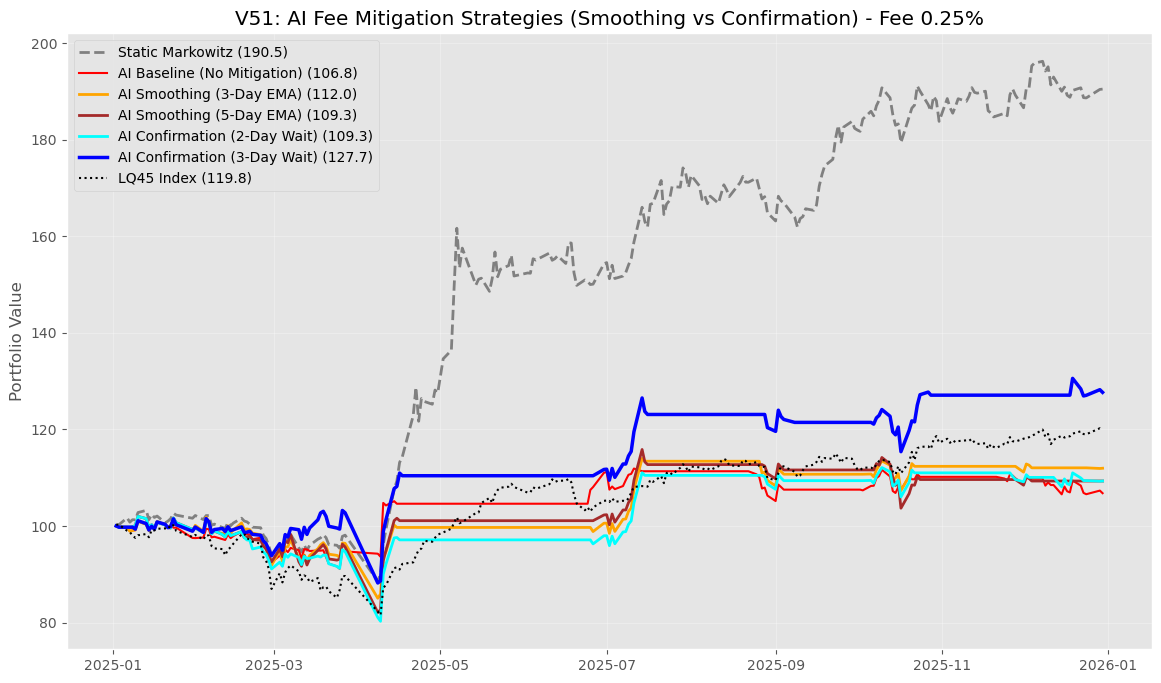

                       Strategy   Return %   Max DD %
0              Static Markowitz  90.482257 -14.178491
5  AI Confirmation (3-Day Wait)  27.675290 -14.551875
6                    LQ45 Index  19.781758 -18.695217
2      AI Smoothing (3-Day EMA)  11.960597 -16.487169
4  AI Confirmation (2-Day Wait)   9.319824 -21.295479
3      AI Smoothing (5-Day EMA)   9.313480 -19.515447
1   AI Baseline (No Mitigation)   6.791724  -9.723880


In [5]:
# --- 5. Visualization & Analysis ---
plt.figure(figsize=(14, 8))

# Define styles for clarity
styles = {
    'Static Markowitz': {'color': 'gray', 'style': '--', 'width': 2},
    'LQ45 Index': {'color': 'black', 'style': ':', 'width': 1.5},
    'AI Baseline (No Mitigation)': {'color': 'red', 'style': '-', 'width': 1.5},
    'AI Smoothing (3-Day EMA)': {'color': 'orange', 'style': '-', 'width': 2},
    'AI Smoothing (5-Day EMA)': {'color': 'brown', 'style': '-', 'width': 2},
    'AI Confirmation (2-Day Wait)': {'color': 'cyan', 'style': '-', 'width': 2},
    'AI Confirmation (3-Day Wait)': {'color': 'blue', 'style': '-', 'width': 2.5}
}

for name, series in results.items():
    s = styles.get(name, {'color': 'purple', 'style': '-', 'width': 1})
    plt.plot(series.index, series, label=f"{name} ({series.iloc[-1]:.1f})", color=s['color'], linestyle=s['style'], linewidth=s['width'])

plt.title('V51: AI Fee Mitigation Strategies (Smoothing vs Confirmation) - Fee 0.25%')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('v51_fee_mitigation_comparison.png')
plt.show()

# Summary Metric Table
summary = []
for name, series in results.items():
    total_ret = (series.iloc[-1] - 100)
    # Calculate Drawdown
    peak = series.cummax()
    dd = (series - peak) / peak
    max_dd = dd.min() * 100
    summary.append({'Strategy': name, 'Return %': total_ret, 'Max DD %': max_dd})

df_summary = pd.DataFrame(summary).sort_values('Return %', ascending=False)
print(df_summary)

df_results = pd.DataFrame(results)
df_results.to_excel('v51_fee_mitigation_results.xlsx')